<a href="https://colab.research.google.com/github/peremartra/optipfair/blob/main/examples/knowledge_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiPFair Notebook Series - Example: Knowledge Distillation
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to use [OptiPFair](https://github.com/peremartra/optipfair) to recover performance after depth pruning using knowledge distillation.  
It follows the full recommended workflow with public APIs only: load a teacher model, create a depth-pruned student, distill knowledge, and visualize training curves.

The benchmark stage with lm_eval is intentionally excluded in this example.

##Recommended Environment

- **Platform**: [Google Colab](https://colab.research.google.com)  
- **Hardware**: GPU A100.
- **Dependencies**: Installed in Section 0

##by Pere Martra.

- [LinkedIn](https://www.linkedin.com/in/pere-martra)  
- [GitHub](https://github.com/peremartra)  
- [X / Twitter](https://x.com/peremartra)

---

> If you find this useful, please ⭐ the [repository](https://github.com/peremartra/optipfair) and share it!

---
If you want your favorite LLM to create code with optiPfair, you just need to provide it with the file: [**optipfair_llm_reference_manual.txt**](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt), which contains all the necessary information for the LLM to become an expert in using the library.

# Knowledge Distillation Example

This notebook demonstrates how to recover a depth-pruned model with OptiPFair knowledge distillation.
We follow the recommended sequence for post-pruning recovery:
1. Load a teacher model
2. Prepare a small recovery dataset
3. Build a depth-pruned student with OptiPFair
4. Recover performance with knowledge distillation using `opf.distill_model()`
5. Plot training losses from `stats['loss_history']`

## 0. Environment and Dependencies\n
First, install the required libraries and define the base configuration.

In [ ]:
!pip install --upgrade git+https://github.com/peremartra/optipfair.git

In [ ]:
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [3]:
RECOVERY_SAMPLES = 40000   # Use a small number for the example
EPOCHS = 4
LEARNING_RATE = 2.5e-5
BATCH_SIZE = 16
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# --- Performance measurement settings (used in Sections 1 and 9) ---
PERF_MAX_NEW_TOKENS = 50
PERF_NUM_RUNS       = 3
PERF_MAX_SAMPLES    = 10

PERF_PROMPT = (
    "The transformer architecture revolutionized natural language processing by introducing"
    " the attention mechanism, which allows the model to focus on relevant parts of the input."
)

PERF_SENTENCES = [
    "The capital of France is",
    "Neural networks learn representations by",
    "The theory of relativity states that",
    "Language models are trained on",
    "Depth pruning reduces the number of layers by",
    "Knowledge distillation transfers information from",
    "The attention mechanism allows transformers to",
    "Gradient descent minimizes the loss function by",
    "The perplexity of a language model measures how",
    "Quantization reduces model size by representing weights in",
]

In [4]:
import torch
from copy import deepcopy
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import optipfair as opf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class DictLoader:
    """Wraps a TensorDataset DataLoader to yield dict batches."""
    def __init__(self, dl): self.dl = dl
    def __iter__(self):
        for ids, mask in self.dl:
            yield {"input_ids": ids, "attention_mask": mask}
    def __len__(self): return len(self.dl)

Using device: cuda


## 1. Load Teacher Model
Load the teacher model in evaluation mode and freeze all its parameters.

The teacher is only used as a supervision signal during distillation.

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"   # or "google/gemma-3-270m" for a smaller option\n

print(f"Loading Teacher model: {MODEL_NAME}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_teacher_layers = teacher_model.config.num_hidden_layers
teacher_n_params  = teacher_model.num_parameters()
print(f"Teacher: {n_teacher_layers} layers, {teacher_n_params:,} params")

In [ ]:
from utils import measure_memory_allocation, measure_detailed_performance

# Build performance loader — tokenizer is now available
perf_enc = tokenizer(
    PERF_SENTENCES,
    padding=True, truncation=True, max_length=64, return_tensors="pt"
)
perf_dataset     = TensorDataset(perf_enc["input_ids"], perf_enc["attention_mask"])
perf_loader      = DataLoader(perf_dataset, batch_size=2)
perf_dict_loader = DictLoader(perf_loader)

# Measure teacher performance (clean GPU — no other model in memory yet)
print("Measuring VRAM (teacher)...")
teacher_vram = measure_memory_allocation(
    teacher_model, tokenizer, PERF_PROMPT, max_new_tokens=PERF_MAX_NEW_TOKENS
)
print("Measuring tokens/sec (teacher)...")
teacher_perf = measure_detailed_performance(
    teacher_model, tokenizer, perf_dict_loader,
    num_runs=PERF_NUM_RUNS, max_new_tokens=PERF_MAX_NEW_TOKENS, max_samples=PERF_MAX_SAMPLES
)
print(f"  Teacher VRAM (static): {teacher_vram['static_vram_mb']:.0f} MB")
print(f"  Teacher throughput:    {teacher_perf['throughput_tokens_per_sec']:.1f} tok/s")

## 2. Prepare Training Dataset
Adapted from NB03: load Cosmopedia in streaming mode, tokenize text, and create an 80/20 train/validation split.

In [ ]:
print("Loading Cosmopedia dataset...")
dataset_name = "HuggingFaceTB/cosmopedia"

# Subsets with fractional weights — must sum to 1.0
# stories x0.30: narrative text → lambada_openai, hellaswag
# web_samples_v2 x0.20: diverse natural language → hellaswag, winogrande
# web_samples_v1 x0.15: general web → baseline coverage
# wikihow x0.15: procedural text → piqa
# openstax x0.125: academic structured → arc_easy
# stanford x0.075: academic dense → arc_easy
subsets = [
    ("stories",        0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow",        0.150),
    ("openstax",       0.125),
    ("stanford",       0.075),
]
# Sanity check
assert abs(sum(w for _, w in subsets) - 1.0) < 1e-6, "Weights must sum to 1.0"

all_samples = []
for subset, weight in subsets:
    n_samples = int(RECOVERY_SAMPLES * weight)
    print(f"  Loading {subset} ({n_samples:,} samples, weight={weight:.3f})...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

In [ ]:
print("Tokenizing...")
texts = [item["text"] for item in distillation_dataset]
tokenized_data = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    tokenized_data.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_data], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_data], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=generator
)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val:   {len(val_dataset):,} samples")

## 3. Create Pruned Student Model
Analyze layer importance with calibration data, remove the least important layers, and prepare the student for training.

In [9]:
print("Analyzing layer importance...")
student_model = deepcopy(teacher_model)
importance_scores = opf.analyze_layer_importance(
    student_model,
    train_dataloader,
    show_progress=True
)

print("\nLayer importance scores (lower = less important):")
for layer_idx, score in sorted(importance_scores.items()):
    print(f"  Layer {layer_idx:2d}: {score:.6f}")

Analyzing layer importance...


Processing batches: 100%|██████████| 2000/2000 [13:44<00:00,  2.43it/s]


Layer importance scores (lower = less important):
  Layer  0: 0.840053
  Layer  1: 0.167785
  Layer  2: 0.198580
  Layer  3: 0.171725
  Layer  4: 0.139043
  Layer  5: 0.122350
  Layer  6: 0.136916
  Layer  7: 0.115219
  Layer  8: 0.073688
  Layer  9: 0.062229
  Layer 10: 0.076621
  Layer 11: 0.094070
  Layer 12: 0.077764
  Layer 13: 0.084449
  Layer 14: 0.118398
  Layer 15: 0.143014
  Layer 16: 0.092676
  Layer 17: 0.072813
  Layer 18: 0.080545
  Layer 19: 0.078758
  Layer 20: 0.058762
  Layer 21: 0.044943
  Layer 22: 0.071217
  Layer 23: 0.273682


In [10]:
LAYERS_TO_REMOVE = sorted(
    importance_scores.keys(),
    key=lambda x: importance_scores[x]
)[:LAYERS_TO_REMOVE_COUNT]

print(f"Layers selected for removal: {LAYERS_TO_REMOVE}")

Layers selected for removal: [21, 20, 9, 22, 17, 8, 10, 12, 19, 18]


In [11]:
student_model = opf.prune_model_depth(
    model=student_model,
    layer_indices=LAYERS_TO_REMOVE,
    show_progress=True
)

for param in student_model.parameters():
    param.requires_grad = True

n_student_layers = student_model.config.num_hidden_layers
print(f"\nTeacher layers: {n_teacher_layers}")
print(f"Student layers: {n_student_layers} (removed {LAYERS_TO_REMOVE})")
print(f"Student params: {student_model.num_parameters():,}")

Removing layers: 100%|██████████| 24/24 [00:00<00:00, 313592.82it/s]


Teacher layers: 24
Student layers: 14 (removed [21, 20, 9, 22, 17, 8, 10, 12, 19, 18])
Student params: 540,042,144


## 4. Knowledge Distillation with OptiPFair
Run labels-only distillation (hard labels + skew KLD) using the OptiPFair public API.

Feature alignment is disabled in this configuration (gamma=0, delta=0).

In [ ]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=0.6,
    beta=0.40,
    gamma=0.0,
    delta=0.0,
    temperature=2,
    skew_alpha=0.3,
    scheduler="cosine",
    warmup_ratio=0.15,
    layer_mapping_strategy="last",
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    accumulation_steps=4,
    show_progress=True,
    return_stats=True,
)

print("\nTraining complete")
print(f"  Total time:        {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"  Avg time/epoch:    {stats['avg_time_per_epoch']:.1f}s")
print(f"  Final total loss:  {stats['loss_history']['total'][-1]:.4f}")
print(f"  Final task loss:   {stats['loss_history']['task'][-1]:.4f}")
print(f"  Final logits loss: {stats['loss_history']['logits'][-1]:.4f}")

## 5. Visualize Training Loss Curves
Plot total, task, and logits losses using the stats dictionary returned by distill_model.

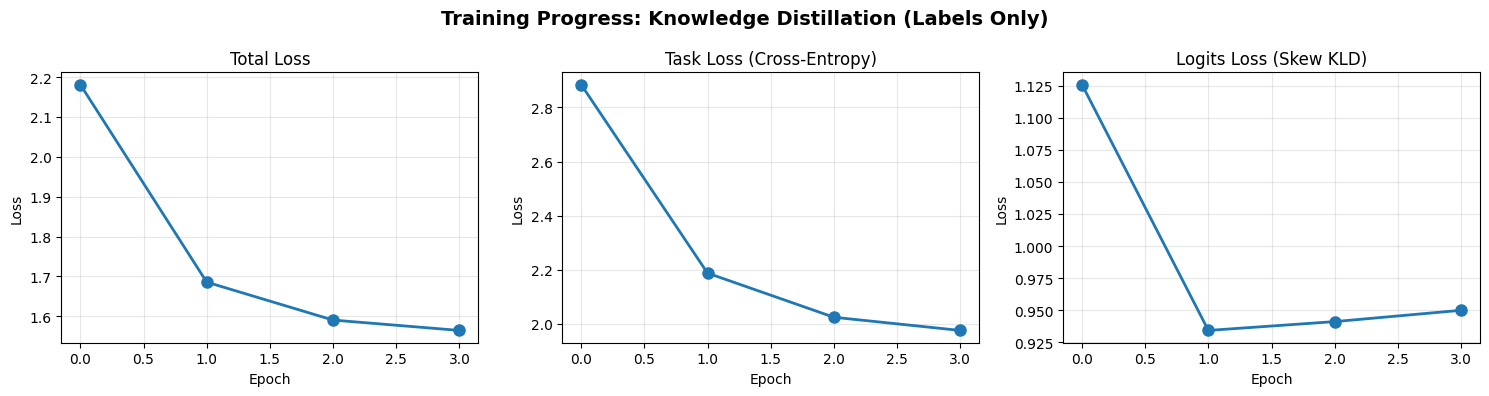

Plot saved to kd_training_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_keys = [
    ("total",  "Total Loss"),
    ("task",   "Task Loss (Cross-Entropy)"),
    ("logits", "Logits Loss (Skew KLD)"),
]

for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(
        stats['loss_history'][key],
        marker='o', linewidth=2, markersize=8
    )
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    'Training Progress: Knowledge Distillation (Labels Only)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('kd_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to kd_training_curves.png")

## 6. Save Student to Hugging Face (Private) + Clear Memory

We push the trained student to a private HF repository, then free **all** GPU memory
(both teacher and student). This ensures each model's performance is measured in isolation:
the teacher was measured in Section 1 on a clean GPU; the student will be measured in
Section 9 after downloading from HF, also on a clean GPU.

This step also serves as an **end-to-end validation**: the benchmarks in Section 7 will run
against the model downloaded from HF, confirming that save + load works correctly.

In [ ]:
import gc

# --- Configure your HF repo name ---
HF_MODEL_NAME = "oopere/qwen3-5-student"  # <-- change to your HF username

# 1. Push trained student (private)
print(f"Pushing student to HF: {HF_MODEL_NAME} (private)...")
trained_student.push_to_hub(HF_MODEL_NAME, private=True)
tokenizer.push_to_hub(HF_MODEL_NAME)
print("  ✓ Student uploaded successfully")

# 2. Delete student from memory — teacher stays
del trained_student, student_model, student_to_train
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("  ✓ Student removed from GPU memory (teacher still loaded)")

# Verify teacher is still in memory
print(f"  Teacher layers in memory: {teacher_model.config.num_hidden_layers}")
if torch.cuda.is_available():
    used_gb = torch.cuda.memory_allocated() / 1e9
    print(f"  GPU memory used: {used_gb:.2f} GB")

## 7. Load Student from HF + Benchmarks

Download the student from HF and evaluate it on 5 standard benchmarks using `lm-eval`.
Teacher scores are hardcoded from a reference run on the same GPU environment
(Qwen3.5-0.8B-Base, A100 40GB, full dataset).

**Why download instead of using the model already in memory?**
This confirms the full serialization pipeline (prune → distill → save → load) works
end-to-end, exactly as a downstream user would experience it.

In [15]:
!pip install -q lm-eval langdetect
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [ ]:
!pip install -q codecarbon
from utils import model_evaluation, clear_gpu_cache
LIMIT_BENCHMARK=400

# Teacher reference scores (Qwen3.5-0.8B-Base, full benchmark run)
TEACHER_SCORES = {
    'arc_easy':       67.5,
    'winogrande':     59.4,
    'hellaswag':      54.9,
    'lambada_openai': 50.9,
    'piqa':           71.5,
}
BENCHMARK_TASKS = list(TEACHER_SCORES.keys())

# Load student from HF
print(f"Loading student from HF: {HF_MODEL_NAME}...")
student_eval = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)
student_eval.eval()
n_student_layers_eval = student_eval.config.num_hidden_layers
print(f"  ✓ Student loaded: {n_student_layers_eval} layers, {student_eval.num_parameters():,} params")

# Run benchmarks
print("\nRunning benchmarks on student (this takes ~10-20 min)...")
student_bench_raw = model_evaluation(
    student_eval, tokenizer, BENCHMARK_TASKS, limit=LIMIT_BENCHMARK, device=str(device), batch_size=8
)

# Extract accuracy scores (lm-eval returns nested dicts)
def extract_acc(results, task):
    r = results.get(task, {})
    for k in ('accuracy', 'acc_norm', 'acc'):  # priority order
        if k in r:
            return float(r[k]) * 100
    return 0.0

student_scores = {t: extract_acc(student_bench_raw, t) for t in BENCHMARK_TASKS}

print("\nBenchmark results:")
print(f"{'Task':<20} {'Teacher':>10} {'Student':>10} {'Retention':>12}")
print("-" * 55)
for task in BENCHMARK_TASKS:
    t = TEACHER_SCORES[task]
    s = student_scores[task]
    ret = (s / t * 100) if t > 0 else 0
    print(f"{task:<20} {t:>9.1f}% {s:>9.1f}% {ret:>10.1f}%")

avg_teacher = sum(TEACHER_SCORES.values()) / len(TEACHER_SCORES)
avg_student = sum(student_scores.values()) / len(student_scores)
cap_retention = avg_student / avg_teacher * 100
print(f"{'AVERAGE':<20} {avg_teacher:>9.1f}% {avg_student:>9.1f}% {cap_retention:>10.1f}%")

## 8. Retention Chart

Visual summary of PPL retention, capabilities retention, and overall retention
for Teacher, Pruned (no KD), and Trained Student.

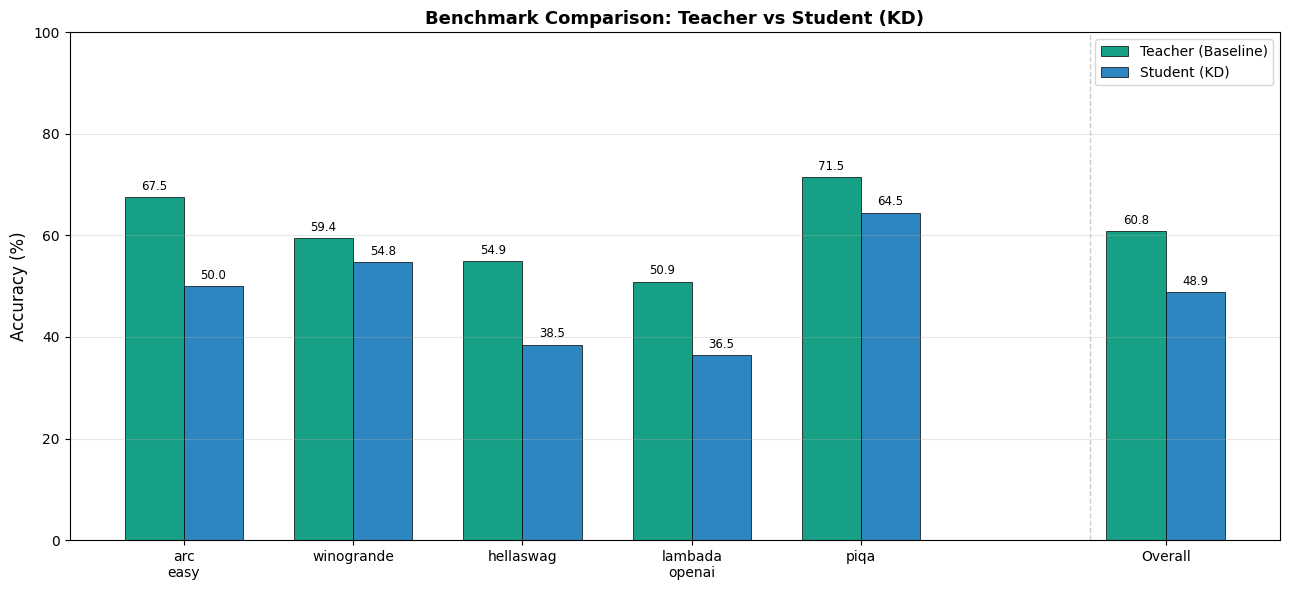

In [17]:
# 8. Benchmark Comparison Chart
import numpy as np

tasks = list(TEACHER_SCORES.keys())
teacher_vals = [TEACHER_SCORES[t] for t in tasks]
student_vals  = [student_scores[t] for t in tasks]

# Add Overall group
tasks_plot        = tasks + ['overall']
teacher_vals_plot = teacher_vals + [avg_teacher]
student_vals_plot = student_vals  + [avg_student]

# x positions — extra gap before Overall
n_tasks  = len(tasks)
x_tasks  = np.arange(n_tasks)
x_overall = np.array([n_tasks + 0.8])   # wider gap here
x_all     = np.concatenate([x_tasks, x_overall])

width   = 0.35
COLOR_TEACHER = '#16a085'
COLOR_STUDENT = '#2e86c1'

fig, ax = plt.subplots(figsize=(13, 6))

bars_t = ax.bar(x_all - width/2, teacher_vals_plot, width,
                label='Teacher (Baseline)', color=COLOR_TEACHER,
                edgecolor='black', linewidth=0.5)
bars_s = ax.bar(x_all + width/2, student_vals_plot, width,
                label='Student (KD)', color=COLOR_STUDENT,
                edgecolor='black', linewidth=0.5)

# Annotations
for bar in list(bars_t) + list(bars_s):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5)

# Vertical separator before Overall
ax.axvline(x=n_tasks + 0.35, color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.6)

labels = [t.replace('_', '\n') for t in tasks] + ['Overall']
ax.set_xticks(x_all)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Benchmark Comparison: Teacher vs Student (KD)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Performance Metrics (VRAM + Tokens/sec)

Measure memory footprint and throughput for the **student** model.
We use `measure_memory_allocation` (static VRAM + dynamic delta from KV cache)
and `measure_detailed_performance` (tokens per second) from `utils.py`.

**The teacher was measured in Section 1 immediately after loading (clean GPU).
The student is measured here after downloading from HF (also on a clean GPU).
This ensures each measurement is taken in isolation for a fair, uncontaminated comparison.**

In [ ]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Rebuild perf loader — tokenizer was re-loaded in Section 7
perf_enc = tokenizer(
    PERF_SENTENCES,
    padding=True, truncation=True, max_length=64, return_tensors="pt"
)
perf_dataset     = TensorDataset(perf_enc["input_ids"], perf_enc["attention_mask"])
perf_loader      = DataLoader(perf_dataset, batch_size=2)
perf_dict_loader = DictLoader(perf_loader)

# Measure student performance (clean GPU — teacher is no longer in memory)
print("Measuring VRAM (student)...")
student_vram = measure_memory_allocation(
    student_eval, tokenizer, PERF_PROMPT, max_new_tokens=PERF_MAX_NEW_TOKENS
)
print("Measuring tokens/sec (student)...")
student_perf = measure_detailed_performance(
    student_eval, tokenizer, perf_dict_loader,
    num_runs=PERF_NUM_RUNS, max_new_tokens=PERF_MAX_NEW_TOKENS, max_samples=PERF_MAX_SAMPLES
)
print(f"  Student VRAM (static): {student_vram['static_vram_mb']:.0f} MB")
print(f"  Student throughput:    {student_perf['throughput_tokens_per_sec']:.1f} tok/s")

## 10. Summary Table

Full comparison: Teacher vs Student across quality, capability, and efficiency metrics.

In [19]:
param_reduction = (
    (teacher_n_params - student_eval.num_parameters())
    / teacher_n_params * 100
)

rows = [
    ('Layers',           f"{n_teacher_layers}",                   f"{student_eval.config.num_hidden_layers}"),
    ('Parameters',       f"{teacher_n_params/1e6:.0f}M",          f"{student_eval.num_parameters()/1e6:.0f}M"),
    ('Param Reduction',  '—',                                               f"{param_reduction:.1f}%"),
]

# Benchmarks
for task in BENCHMARK_TASKS:
    rows.append((task.replace('_', ' ').title(),
                 f"{TEACHER_SCORES[task]:.1f}%",
                 f"{student_scores[task]:.1f}%"))

rows.append(('Avg Benchmark',
             f"{avg_teacher:.1f}%",
             f"{avg_student:.1f}% ({cap_retention:.1f}% retained)"))

# VRAM
rows.append(('Static VRAM',
             f"{teacher_vram['static_vram_mb']:.0f} MB",
             f"{student_vram['static_vram_mb']:.0f} MB"))
rows.append(('Dynamic VRAM (KV cache delta)',
             f"{teacher_vram['dynamic_delta_mb']:.0f} MB",
             f"{student_vram['dynamic_delta_mb']:.0f} MB"))

# TPS
rows.append(('Throughput (tok/s)',
             f"{teacher_perf['throughput_tokens_per_sec']:.1f}",
             f"{student_perf['throughput_tokens_per_sec']:.1f}"))
rows.append(('Avg Latency (s)',
             f"{teacher_perf['avg_latency_sec']:.3f}",
             f"{student_perf['avg_latency_sec']:.3f}"))

# Print table
col_w = [35, 22, 36]
sep   = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
header = f"| {'Metric':<{col_w[0]}} | {'Teacher':^{col_w[1]}} | {'Student (KD)':^{col_w[2]}} |"
print(sep); print(header); print(sep)
for label, t_val, s_val in rows:
    print(f"| {label:<{col_w[0]}} | {t_val:^{col_w[1]}} | {s_val:^{col_w[2]}} |")
print(sep)

+-------------------------------------+------------------------+--------------------------------------+
| Metric                              |        Teacher         |             Student (KD)             |
+-------------------------------------+------------------------+--------------------------------------+
| Layers                              |           24           |                  14                  |
| Parameters                          |          752M          |                 540M                 |
| Param Reduction                     |           —            |                28.2%                 |
| Arc Easy                            |         67.5%          |                50.0%                 |
| Winogrande                          |         59.4%          |                54.8%                 |
| Hellaswag                           |         54.9%          |                38.5%                 |
| Lambada Openai                      |         50.9%          |

In [20]:
teacher_vram['generated_text']

' This mechanism enables the model to attend to different parts of the input, improving its ability to understand and generate text. The transformer architecture, which is a type of neural network, has been widely used in various applications, including text generation, where it can'

In [21]:
student_vram['generated_text']

' This feature has been instrumental in improving the overall performance of various applications, including machine learning algorithms and natural language processing (NLP). However, despite its benefits, attention has also introduced challenges, particularly when it comes to understanding and predicting the natural language context'